In [35]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error
import numpy as np
import scipy as scp
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.neighbors import KNeighborsRegressor
from pandas.plotting import scatter_matrix
print("LIBRARIES IMPORTED")


LIBRARIES IMPORTED


In [36]:
data = pd.read_csv("c4.csv")

In [37]:
data.head(3)

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0


In [38]:
data.columns

Index(['Make', 'Model', 'Price', 'Year', 'Kilometer', 'Fuel Type',
       'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Engine',
       'Max Power', 'Max Torque', 'Drivetrain', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capacity'],
      dtype='object')

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [40]:
data.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


array([[<Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Kilometer'}>],
       [<Axes: title={'center': 'Length'}>,
        <Axes: title={'center': 'Width'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Seating Capacity'}>,
        <Axes: title={'center': 'Fuel Tank Capacity'}>, <Axes: >]],
      dtype=object)

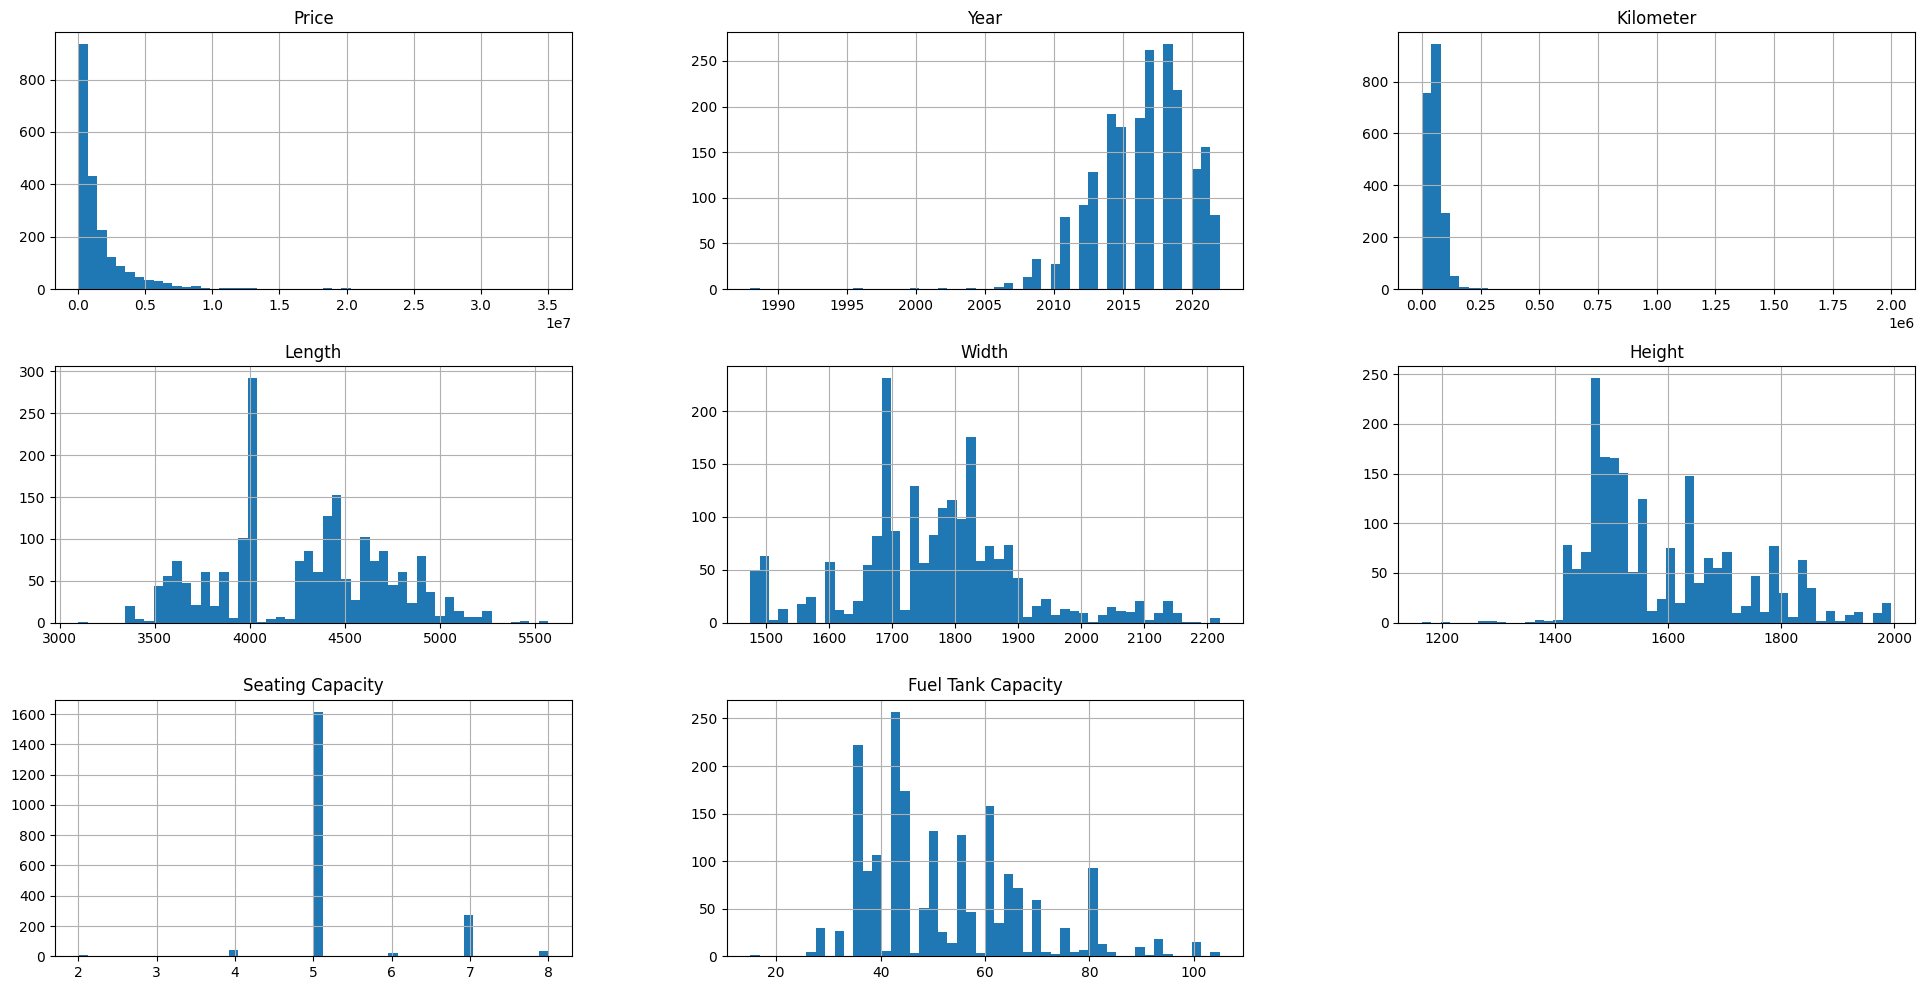

In [41]:
data.hist(bins=50, figsize=(24,12))

In [42]:
corr = data.corr(numeric_only=True)
corr['Price'].sort_values(ascending=False)

Price                 1.000000
Fuel Tank Capacity    0.584631
Width                 0.563996
Length                0.556741
Year                  0.311400
Height                0.075080
Seating Capacity     -0.038524
Kilometer            -0.150825
Name: Price, dtype: float64

array([[<Axes: xlabel='Price', ylabel='Price'>,
        <Axes: xlabel='Fuel Tank Capacity', ylabel='Price'>,
        <Axes: xlabel='Width', ylabel='Price'>,
        <Axes: xlabel='Length', ylabel='Price'>,
        <Axes: xlabel='Year', ylabel='Price'>],
       [<Axes: xlabel='Price', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Fuel Tank Capacity', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Width', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Length', ylabel='Fuel Tank Capacity'>,
        <Axes: xlabel='Year', ylabel='Fuel Tank Capacity'>],
       [<Axes: xlabel='Price', ylabel='Width'>,
        <Axes: xlabel='Fuel Tank Capacity', ylabel='Width'>,
        <Axes: xlabel='Width', ylabel='Width'>,
        <Axes: xlabel='Length', ylabel='Width'>,
        <Axes: xlabel='Year', ylabel='Width'>],
       [<Axes: xlabel='Price', ylabel='Length'>,
        <Axes: xlabel='Fuel Tank Capacity', ylabel='Length'>,
        <Axes: xlabel='Width', ylabel='Length'>,
        <Axes

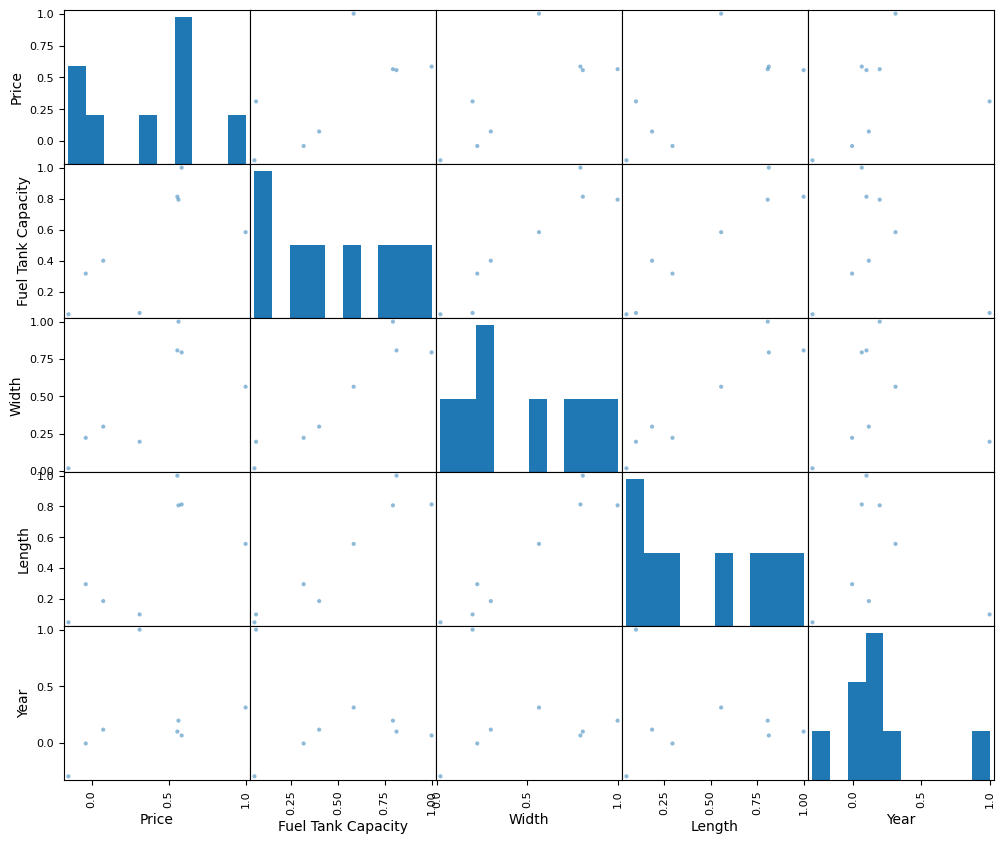

In [43]:
feat =  ['Price', 'Fuel Tank Capacity', 'Width', 'Length', 'Year']
scatter_matrix(corr[feat], figsize=(12,10))

In [44]:
data.Price

0        505000
1        450000
2        220000
3        799000
4       1950000
         ...   
2054     850000
2055     275000
2056     240000
2057    4290000
2058     670000
Name: Price, Length: 2059, dtype: int64

In [92]:
data["Price"] = pd.cut(data['Price'],
                       bins=[0.25, 0.5, 0.75, 1.,np.inf],
                       labels=[1, 2, 3, 4]
                       )
train_set, test_set = train_test_split(data, train_size=0.8, test_size=0.2, random_state=42, stratify=data["Price"])
train_set, val_set = train_test_split(train_set, train_size=0.7, test_size=0.3, random_state=42, stratify=train_set["Price"])

In [93]:
categorical_cols = [i for i in train_set if train_set[i].dtypes in ['object', '0']]
numerical_cols = [i for i in train_set if train_set[i].dtypes in ['int64', 'float64']]

In [94]:
len(data.columns)

20

In [95]:
len(categorical_cols)

12

In [96]:
len(numerical_cols)

7

In [98]:
len(train_set)

1152